In [61]:
from google.colab import drive
drive.mount('/content/gdrive/')

Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).


In [62]:
!pip3 install tslearn

In [63]:
import os
from os import listdir
import random
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import math
import sys
from glob import glob
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tslearn.datasets import UCR_UEA_datasets
from tslearn.preprocessing import TimeSeriesScalerMeanVariance, TimeSeriesResampler, TimeSeriesScalerMinMax
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy import stats
import keras
from keras import layers, models
from keras.layers import Dense, BatchNormalization, LSTM, Flatten, TimeDistributed, Dropout, GlobalMaxPooling2D, GlobalMaxPooling1D, MaxPooling2D, MaxPooling1D, Conv2D, Conv1D, Input, Reshape, ConvLSTM2D
from tslearn.preprocessing import TimeSeriesScalerMinMax
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import numpy
from sklearn import metrics

## Load in Data

In [64]:
# import csv
path = "/content/gdrive/MyDrive/Next_Step/Honda: multi_modal_gait_database/merged/interpolated_alt_seg_insole_sensor_df.csv"

interpolated_final_df = pd.read_csv(path)

In [65]:
interpolated_final_df['gait_cycle_id'] = interpolated_final_df['participant_id'].astype(str) + '_' + interpolated_final_df['task'].astype(str) + '_' + interpolated_final_df['segment_count'].astype(str)

In [66]:

interpolated_final_df.sort_values(by=['participant_id', 'task', 'time', 'sensor_location'], inplace=True)

In [67]:
interpolated_final_df['time'] = (interpolated_final_df['time'] * 1000).astype(int)
interpolated_final_df['Left_norm'] = (interpolated_final_df['Left_norm'] * 1000).astype(int)
interpolated_final_df['Right_norm'] = (interpolated_final_df['Right_norm'] * 1000).astype(int)
interpolated_final_df['Left_norm_cumulative'] = (interpolated_final_df['Left_norm_cumulative'] * 1000).astype(int)
interpolated_final_df['Right_norm_cumulative'] = (interpolated_final_df['Right_norm_cumulative'] * 1000).astype(int)

In [68]:
# convert all to int except for sensor_location and gait_cycle_id
interpolated_final_df['participant_id'] = interpolated_final_df['participant_id'].astype(int)
interpolated_final_df['task'] = interpolated_final_df['task'].astype(int)
interpolated_final_df['segment_count'] = interpolated_final_df['segment_count'].astype(int)
interpolated_final_df['time'] = interpolated_final_df['time'].astype(int)
interpolated_final_df['Left_norm'] = interpolated_final_df['Left_norm'].astype(int)
interpolated_final_df['Right_norm'] = interpolated_final_df['Right_norm'].astype(int)
interpolated_final_df['Left_norm_cumulative'] = interpolated_final_df['Left_norm_cumulative'].astype(int)
interpolated_final_df['Right_norm_cumulative'] = interpolated_final_df['Right_norm_cumulative'].astype(int)
interpolated_final_df['walk_mode'] = interpolated_final_df['walk_mode'].astype(int)

In [69]:
interpolated_final_df['walk_mode'].value_counts()

,count
walk_mode,
4,25071360
0,8206080
1,6081920
3,3449600
2,1934080


In [70]:
import random

number_list = list(interpolated_final_df['participant_id'].unique())

# Choose 3 numbers without replacement
test_three_numbers = random.sample(number_list, 2)
print(test_three_numbers)
train_list = [x for x in number_list if x not in test_three_numbers]

val_three_numbers = random.sample(train_list, 2)
print(val_three_numbers)

train_list = [x for x in train_list if x not in val_three_numbers]
print(train_list)

[3, 13]
[4, 22]
[1, 2, 5, 7, 8, 10, 12, 14, 15, 16, 17, 18, 19]


In [71]:
train = interpolated_final_df.loc[interpolated_final_df['participant_id'].isin(train_list)]
val = interpolated_final_df.loc[interpolated_final_df['participant_id'].isin(val_three_numbers)]
test = interpolated_final_df.loc[interpolated_final_df['participant_id'].isin(test_three_numbers)]

In [72]:
# retain only the first instance of gait_cycle_id
train_unique = train.drop_duplicates(subset=['gait_cycle_id'], keep='first')

In [73]:
# Oversample smaller classes to balance the dataset
min_samples = int(train_unique['walk_mode'].value_counts().min())

In [74]:
min_samples

2478

In [75]:
# Downsample to balance classes
balanced_gait_cycles = (
    train_unique.groupby('walk_mode')
    .apply(lambda group: group.sample(n=min_samples, replace=False, random_state=42))
    .reset_index(drop=True)
)

<ipython-input-75-e6181ac3816b>:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.sample(n=min_samples, replace=False, random_state=42))


In [76]:
print(balanced_gait_cycles['walk_mode'].value_counts())

walk_mode
0    2478
1    2478
2    2478
3    2478
4    2478
Name: count, dtype: int64


In [77]:
filtered_interpolated_final_df = pd.merge(
    train,
    balanced_gait_cycles[['gait_cycle_id']],
    on='gait_cycle_id',
    how='inner'
)

In [78]:
filtered_interpolated_final_df.head()

,time,participant_id,task,Left_norm,Right_norm,Left_norm_cumulative,Right_norm_cumulative,segment_count,walk_mode,sensor_location,gait_cycle_id
0,3150000,1,0,880,45,2730,287,10,2,Arch,1.0_0.0_10.0
1,3150000,1,0,0,55,2730,287,10,2,Hallux,1.0_0.0_10.0
2,3150000,1,0,905,0,2730,287,10,2,Heel_L,1.0_0.0_10.0
3,3150000,1,0,612,0,2730,287,10,2,Heel_R,1.0_0.0_10.0
4,3150000,1,0,1,184,2730,287,10,2,Met1,1.0_0.0_10.0


In [79]:
filtered_interpolated_final_df['participant_id'].unique()

array([ 1,  2,  5,  7,  8, 10, 12, 14, 15, 16, 17, 18, 19])

In [80]:
filtered_interpolated_final_df['gait_cycle_id'].value_counts()

,count
gait_cycle_id,
1.0_0.0_10.0,640
15.0_0.0_1758.0,640
15.0_0.0_1884.0,640
15.0_0.0_1888.0,640
15.0_0.0_1890.0,640
...,...
8.0_0.0_1843.0,640
8.0_0.0_1844.0,640
8.0_0.0_1845.0,640


In [81]:
train = filtered_interpolated_final_df.copy()

In [82]:
total_num = 0
for p in  train['participant_id'].unique():
    participant_1 = train[train['participant_id'] == p]
    pant_num = participant_1['segment_count'].nunique()
    total_num += pant_num
print(total_num)

10789


In [83]:
train['walk_mode'].value_counts()

,count
walk_mode,
2,1585920
4,1585920
3,1585920
0,1585920
1,1585920


In [84]:
train['participant_id'].value_counts()

,count
participant_id,
12,709760
18,707200
10,648320
8,641280
14,637440
1,630400
15,615680
16,605440
7,582400


In [85]:
le = LabelEncoder()

train['gait_cycle_id'] = le.fit_transform(train['gait_cycle_id'])
train['sensor_location'] = le.fit_transform(train['sensor_location'])
train['task'] = le.fit_transform(train['task'])
train['walk_mode'] = le.fit_transform(train['walk_mode'])

val['gait_cycle_id'] = le.fit_transform(val['gait_cycle_id'])
val['sensor_location'] = le.fit_transform(val['sensor_location'])
val['task'] = le.fit_transform(val['task'])
val['walk_mode'] = le.fit_transform(val['walk_mode'])

test['gait_cycle_id'] = le.fit_transform(test['gait_cycle_id'])
test['sensor_location'] = le.fit_transform(test['sensor_location'])
test['task'] = le.fit_transform(test['task'])
test['walk_mode'] = le.fit_transform(test['walk_mode'])

<ipython-input-85-b990848ca3d9>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val['gait_cycle_id'] = le.fit_transform(val['gait_cycle_id'])
<ipython-input-85-b990848ca3d9>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val['sensor_location'] = le.fit_transform(val['sensor_location'])
<ipython-input-85-b990848ca3d9>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation:

In [86]:
train['walk_mode'].value_counts()

,count
walk_mode,
2,1585920
4,1585920
3,1585920
0,1585920
1,1585920


In [87]:
print(train.isnull().sum())

time                     0
participant_id           0
task                     0
Left_norm                0
Right_norm               0
Left_norm_cumulative     0
Right_norm_cumulative    0
segment_count            0
walk_mode                0
sensor_location          0
gait_cycle_id            0
dtype: int64


In [88]:
def preprocess_data(df):
    all_data_x = []
    all_labels_y = []

    for gait_cycle_id, group_data in df.groupby('gait_cycle_id'):
        # Sort by time to ensure consistent order
        group_data = group_data.sort_values(by='time')

        # Prepare a 2D array to hold data for the current gait cycle (80, 18)
        segment_data = []

        # Group by sensor location and extract data in the desired order
        sensor_data_dict = {}
        for sensor_location, sensor_data in group_data.groupby('sensor_location'):
            sensor_array = sensor_data[['Left_norm', 'Right_norm']].values
            sensor_data_dict[sensor_location] = sensor_array

        # Ensure all sensor data has the same time length (80)
        for sensor_location in sorted(sensor_data_dict.keys()):
            sensor_array = sensor_data_dict[sensor_location]
            if len(sensor_array) < 80:
                # Pad with zeros if shorter
                padding = np.zeros((80 - len(sensor_array), 2))
                sensor_array = np.vstack([sensor_array, padding])
            elif len(sensor_array) > 80:
                # Truncate if longer
                sensor_array = sensor_array[:80]

            segment_data.append(sensor_array)

        # Add cumulative data
        cumulative_data = group_data[['Left_norm_cumulative', 'Right_norm_cumulative']].values[:80]
        if len(cumulative_data) < 80:
            padding = np.zeros((80 - len(cumulative_data), 2))
            cumulative_data = np.vstack([cumulative_data, padding])

        segment_data.append(cumulative_data)

        # Combine all sensor data into the final 2D array for the segment (80, 18)
        segment_data = np.hstack(segment_data)
        all_data_x.append(segment_data)

        # Extract labels for the gait cycle
        walk_mode_data = group_data['walk_mode'].values[:80]
        if len(walk_mode_data) < 80:
            walk_mode_data = np.pad(walk_mode_data, (0, 80 - len(walk_mode_data)), constant_values=-1)  # Use -1 for padding

        all_labels_y.append(walk_mode_data)

    # Convert lists to NumPy arrays
    all_data_x = np.array(all_data_x)  # Shape: [x, 80, 18]
    all_labels_y = np.array(all_labels_y)  # Shape: [x, 80]

    return all_data_x, all_labels_y


In [89]:
train_all_data_x, train_all_labels_y = preprocess_data(train)

In [90]:
val_all_data_x, val_all_labels_y = preprocess_data(val)

In [91]:
test_all_data_x, test_all_labels_y = preprocess_data(test)

In [92]:
train_all_labels_y = np.swapaxes(train_all_labels_y, 0, 1)
train_all_labels_y = train_all_labels_y[0]

val_all_labels_y = np.swapaxes(val_all_labels_y, 0, 1)
val_all_labels_y = val_all_labels_y[0]

test_all_labels_y = np.swapaxes(test_all_labels_y, 0, 1)
test_all_labels_y = test_all_labels_y[0]

In [93]:
from keras.utils import to_categorical

# Assuming the labels are already numeric
train_all_labels_y = to_categorical(train_all_labels_y)
val_all_labels_y = to_categorical(val_all_labels_y)
test_all_labels_y = to_categorical(test_all_labels_y)

In [94]:
train_all_labels_y.shape, train_all_labels_y[0]

((12390, 5), array([0., 0., 1., 0., 0.]))

In [95]:
train_all_data_x.shape, train_all_labels_y.shape, val_all_data_x.shape, val_all_labels_y.shape, test_all_data_x.shape, test_all_labels_y.shape

((12390, 80, 18),
 (12390, 5),
 (4403, 80, 18),
 (4403, 5),
 (8598, 80, 18),
 (8598, 5))

In [96]:
train_X = train_all_data_x
train_Y = train_all_labels_y

val_X = val_all_data_x
val_Y = val_all_labels_y

test_X = test_all_data_x
test_Y = test_all_labels_y

In [97]:
n_obs, n_timesteps, n_features, n_classes = train_X.shape[0], train_X.shape[1], train_X.shape[2], train_Y.shape[1]

In [98]:
n_obs, n_timesteps, n_features, n_classes

(12390, 80, 18, 5)

## hyperparameter tuning

In [99]:
!pip install scikeras

In [100]:
train_X.shape, train_Y.shape

((12390, 80, 18), (12390, 5))

In [101]:
val_X.shape, val_Y.shape

((4403, 80, 18), (4403, 5))

In [102]:
# Clears the session for TensorFlow
tf.keras.backend.clear_session()

In [103]:
# import tensorflow as tf
# from tensorflow.keras.layers import Input, Conv1D, LSTM, Attention, Concatenate, Dense, Bidirectional, BatchNormalization, MaxPooling1D, Dropout, Flatten
# from sklearn.model_selection import GridSearchCV
# from scikeras.wrappers import KerasClassifier
# from tensorflow.keras.callbacks import EarlyStopping

# # Function to create the Keras model
# def create_model(input_shape=(80, 18), cnn_units=128, learning_rate=0.001, dropout=0.4, lstm_units=64, n_classes=5):

#     # Clears the session for TensorFlow
#     tf.keras.backend.clear_session()

#     inputs = Input(shape=input_shape)

#     # CNN layer
#     cnn_out = BatchNormalization()(inputs)
#     cnn_out = Conv1D(cnn_units, kernel_size=3, activation='relu')(cnn_out)
#     cnn_out = MaxPooling1D(pool_size=2)(cnn_out)
#     cnn_out = Dropout(dropout)(cnn_out)

#     # Bidirectional LSTM layer
#     lstm_out = Bidirectional(LSTM(units=lstm_units, dropout=0.4, recurrent_dropout=0.4, return_sequences=True))(cnn_out)

#     # Attention layer
#     attention = Attention()([cnn_out, lstm_out])

#     # Concatenate attention output with LSTM output
#     merged = Concatenate(axis=-1)([lstm_out, attention])

#     # MLP layer after attention and LSTM output
#     mlp_out = Flatten()(merged)
#     mlp_out = Dense(128, activation='relu')(mlp_out)
#     mlp_out = Dense(64, activation='relu')(mlp_out)
#     output_layer = Dense(n_classes, activation='softmax')(mlp_out)

#     # Model compilation
#     model = tf.keras.models.Model(inputs=inputs, outputs=output_layer)
#     optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
#     model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

#     return model


# # Wrap the model with KerasClassifier
# model = KerasClassifier(model=create_model, input_shape=(80, 18), verbose=2)

# # Define hyperparameter grid using double underscores for parameter names
# param_grid = {
#     'model__cnn_units': [64, 128, 256],  # Number of filters for the CNN layer
#     'model__learning_rate': [0.001, 0.0001, 0.00001],
#     'model__dropout': [0.3, 0.4, 0.5],
#     'model__lstm_units': [32, 64, 128],
#     'model__n_classes': [5]  # Number of classes for classification (fixed as per your data)
# }

# # Create the GridSearchCV object
# grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=None, scoring='accuracy')

# # Define the early stopping callback
# early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# # Fit the grid search with early stopping
# grid_result = grid.fit(train_X, train_Y, validation_data=(val_X, val_Y), callbacks=[early_stopping])

# # Print the best result
# print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))


## Train Model

In [104]:
!pip install shap

In [121]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, LSTM, Layer, Attention, Concatenate, Dense, Bidirectional, BatchNormalization, MaxPooling1D, Dropout, Flatten
from sklearn.model_selection import train_test_split

# Clears the session for TensorFlow
tf.keras.backend.clear_session()

# Define input shape and number of inputs
input_shape = (n_timesteps, n_features)
number_of_inputs = n_obs
number_of_sensors = len(train_X)
inputs = []

attention_weights_list = []  # To store attention weights for each branch
count = 0


input_layer = Input(shape=input_shape)
inputs.append(input_layer)

# CNN layer
cnn_out = BatchNormalization()(input_layer)
cnn_out = Conv1D(filters=128, kernel_size=3, activation='relu')(cnn_out)
cnn_out = MaxPooling1D(pool_size=2)(cnn_out)
cnn_out = Dropout(0.45)(cnn_out)

# Bidirectional LSTM layer
lstm_out = Bidirectional(LSTM(units=64, dropout=0.4, recurrent_dropout=0.4, return_sequences=True))(cnn_out)

# Attention layer
attention = Attention()([cnn_out, lstm_out])
# Concatenate attention output with LSTM output
merged = Concatenate(axis=-1)([lstm_out, attention])
# Dense layer for individual branch output
merged_output = Dense(units=n_classes, activation='softmax')(merged)

# MLP layer
mlp_out = Flatten()(merged_output)
mlp_out = Dense(units=128, activation='relu')(mlp_out)
mlp_out = Dense(units=64, activation='relu')(mlp_out)
output_layer = Dense(units=n_classes, activation='softmax')(mlp_out)

# Model outputs both classification and attention weights
model = tf.keras.models.Model(inputs=inputs, outputs=[output_layer])

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8)

# Compile the model
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 80, 18)         │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 80, 18)         │             72 │ input_layer[0][0]      │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d (Conv1D)           │ (None, 78, 128)        │          7,040 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d             │ (None, 39, 128)        │              0 │ conv1d[0][0]           │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 39, 128)        │              0 │ max_pooling1d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional             │ (None, 39, 128)        │         98,816 │ dropout[0][0]          │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention (Attention)     │ (None, 39, 128)        │              0 │ dropout[0][0],         │
│                           │                        │                │ bidirectional[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 39, 256)        │              0 │ bidirectional[0][0],   │
│                           │                        │                │ attention[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 39, 5)          │          1,285 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten (Flatten)         │ (None, 195)            │              0 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 128)            │         25,088 │ flatten[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 64)             │          8,256 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)           │ (None, 5)              │            325 │ dense_2[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 140,882 (550.32 KB)

 Trainable params: 140,846 (550.18 KB)

 Non-trainable params: 36 (144.00 B)

In [122]:
# Assuming each entry in train_X_split_trimmed corresponds to one sensor's data
# Make sure that train_X_split_trimmed has exactly 6 entries for the 6 sensors
history = model.fit(train_X, train_Y, epochs=200, batch_size=128, callbacks=[callback], validation_data=(val_X, val_Y))


Epoch 1/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 15s 91ms/step - accuracy: 0.3560 - loss: 1.3198 - val_accuracy: 0.2380 - val_loss: 1.4622
Epoch 2/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.6653 - loss: 0.7594 - val_accuracy: 0.4068 - val_loss: 1.2668
Epoch 3/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.7693 - loss: 0.5565 - val_accuracy: 0.6007 - val_loss: 0.9177
Epoch 4/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.8152 - loss: 0.4438 - val_accuracy: 0.5194 - val_loss: 1.1482
Epoch 5/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.8361 - loss: 0.3994 - val_accuracy: 0.6309 - val_loss: 0.8994
Epoch 6/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.8624 - loss: 0.3470 - val_accuracy: 0.6979 - val_loss: 0.7083
Epoch 7/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.8645 - loss: 0.3366 - val_accuracy: 0.6439 - val_loss: 0.8435
Epoch 8/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.8686 - loss: 0.3201 - val_accuracy: 0

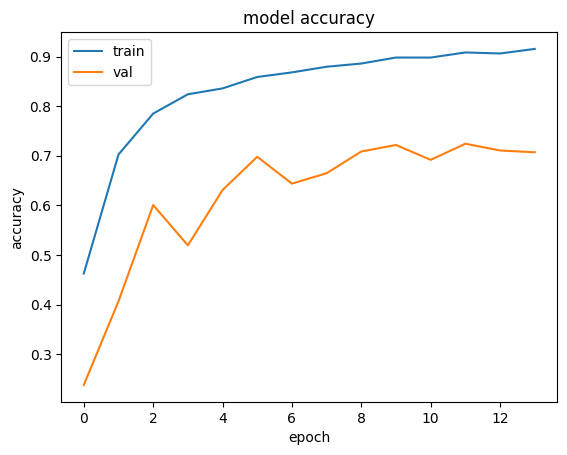

In [123]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

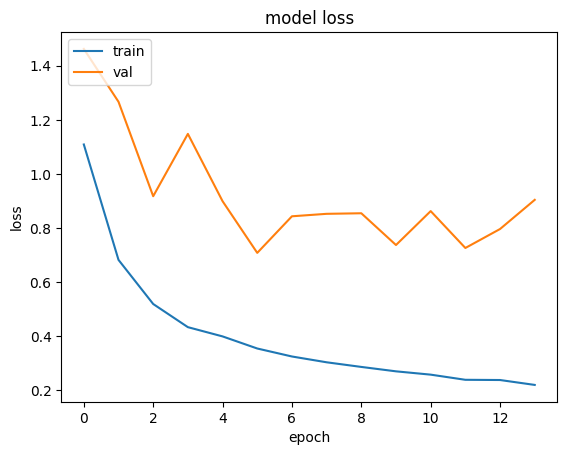

In [124]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [125]:
test_loss, test_accuracy = model.evaluate(test_X, test_Y)

269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.3025 - loss: 3.4646


In [126]:
# Check shapes of test data before evaluation
print("Test X shape:", test_X[0].shape)
print("Test Y shape:", test_Y[0].shape)

Test X shape: (80, 18)
Test Y shape: (5,)


In [127]:
#predictions
predictions = model.predict(test_X)

269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


In [128]:
# Convert predictions to class labels
predicted_classes = tf.argmax(predictions, axis=-1)

# Convert true labels to class labels (if needed)
true_classes = tf.argmax(test_Y, axis=-1)

# Calculate accuracy
accuracy = tf.reduce_mean(tf.cast(tf.equal(predicted_classes, true_classes), tf.float32))
print(f"Test accuracy: {accuracy.numpy() * 100:.2f}%")

# Display predicted and true classes for further inspection
print("Predicted classes:", predicted_classes.numpy())
print("True classes:", true_classes.numpy())

Test accuracy: 31.30%
Predicted classes: [1 2 2 ... 4 4 1]
True classes: [4 4 3 ... 4 4 4]


In [129]:
from sklearn.metrics import classification_report
from sklearn.metrics import recall_score

# Convert predictions and true labels to NumPy arrays
# The variables are already numpy arrays, so no conversion is needed.
predicted_classes_np = predicted_classes
true_classes_np = true_classes

# Generate a classification report (includes precision, recall, F1-score for each class)
report = classification_report(true_classes_np, predicted_classes_np, digits=4)
print("Classification Report:\n", report)

# Compute confusion matrix
conf_matrix = confusion_matrix(true_classes_np, predicted_classes_np)
print("Confusion Matrix:\n", conf_matrix)

# Calculate F1-score and sensitivity (recall) per class
f1_scores = recall_score(true_classes_np, predicted_classes_np, average=None)
print(f"F1-Scores (per class): {f1_scores}")

# Custom calculation for specificity per class
specificities = []
for i in range(conf_matrix.shape[0]):
    tn = conf_matrix.sum() - (conf_matrix[i, :].sum() + conf_matrix[:, i].sum() - conf_matrix[i, i])
    fp = conf_matrix[:, i].sum() - conf_matrix[i, i]
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    specificities.append(specificity)

print(f"Specificities (per class): {specificities}")

Classification Report:
               precision    recall  f1-score   support

           0     0.9659    0.1931    0.3218      1616
           1     0.2059    0.9957    0.3413      1172
           2     0.5712    0.9149    0.7033       329
           3     0.9121    0.6441    0.7551       725
           4     0.2830    0.0934    0.1404      4756

    accuracy                         0.3130      8598
   macro avg     0.5876    0.5682    0.4524      8598
weighted avg     0.4649    0.3130    0.2752      8598

Confusion Matrix:
 [[ 312  193    5    0 1106]
 [   0 1167    0    0    5]
 [   5    6  301    9    8]
 [   0   44  208  467    6]
 [   6 4257   13   36  444]]
F1-Scores (per class): [0.19306931 0.99573379 0.91489362 0.64413793 0.09335576]
Specificities (per class): [0.9984245201947866, 0.39402100727174794, 0.9726690047164107, 0.9942842626698845, 0.7071837584591358]


In [130]:
from sklearn.metrics import classification_report
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score # Import the f1_score function
from sklearn.metrics import precision_recall_fscore_support

# Calculate F1-score and sensitivity (recall) per class
f1_scores = recall_score(true_classes_np, predicted_classes_np, average=None)
print(f"F1-Scores (per class): {f1_scores}")
f1 = f1_score(true_classes_np, predicted_classes_np, average='weighted')
# overall F1 score average
overall_F1 = round(math.fsum(f1_scores) / len(f1_scores),2)
print(f"Overall F1 Score: {overall_F1}")


F1-Scores (per class): [0.19306931 0.99573379 0.91489362 0.64413793 0.09335576]
Overall F1 Score: 0.57


In [131]:
from sklearn.metrics import precision_recall_fscore_support
res = []
for l in [0,1,2,3,4]:
     prec,recall,_,_ = precision_recall_fscore_support(np.array(true_classes_np)==l,
                                                  np.array(predicted_classes_np)==l,
                                                  pos_label=True,average=None)
     res.append([l,recall[0],recall[1]])

sens_spes = pd.DataFrame(res,columns = ['class','specificity','sensitivity'])
print(sens_spes)

overall_specificity = sens_spes['specificity'].mean()
overall_sensitivity = sens_spes['sensitivity'].mean()
print(f"Overall specificity: {round(overall_specificity,2)}")
print(f"Overall sensitivity: {round(overall_sensitivity, 2)}")

   class  specificity  sensitivity
0      0     0.998425     0.193069
1      1     0.394021     0.995734
2      2     0.972669     0.914894
3      3     0.994284     0.644138
4      4     0.707184     0.093356
Overall specificity: 0.81
Overall sensitivity: 0.57


## Confusion Matrix

In [132]:
# Compute the confusion matrix
result = confusion_matrix(true_classes, predicted_classes)

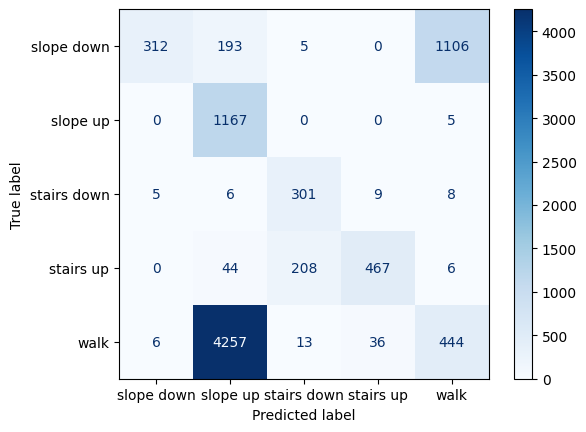

In [133]:
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = result, display_labels = ['slope down', 'slope up', 'stairs down', 'stairs up', 'walk'])

cm_display.plot(cmap=plt.cm.Blues)
plt.show()

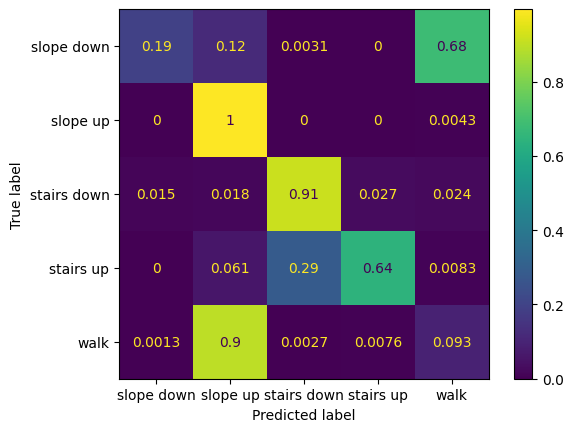

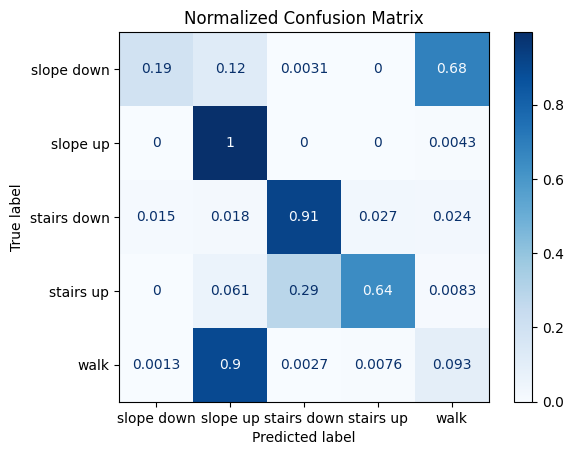

In [134]:
# Create the confusion matrix display using the from_predictions method
cm_display = ConfusionMatrixDisplay.from_predictions(
    true_classes,
    predicted_classes,
    display_labels=['slope down', 'slope up', 'stairs down', 'stairs up', 'walk'],
    normalize='true'  # Normalize by the true labels
)

cm_display.plot(cmap=plt.cm.Blues)
plt.title("Normalized Confusion Matrix")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [135]:
# 0 GR, 1 BNKR, 2 BNKL, 3 SLPD, 4 SLPU, 5 STD, 6 STU, 7 CS, 8 FE

In [136]:
# 0 GR, 1 SLPD, 2 SLPU, 3 STD, 4 STU, 5 CS, 6 FE